In [24]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/varunrajput/beed-bangalore-eeg-epilepsy-dataset/BEED_Data.csv
/kaggle/input/datasets/subirbiswas19/eeg-dataset/EEG_Scaled_data.csv
/kaggle/input/datasets/harunshimanto/epileptic-seizure-recognition/Epileptic Seizure Recognition.csv


In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("/kaggle/input/datasets/harunshimanto/epileptic-seizure-recognition/Epileptic Seizure Recognition.csv")

df = df.drop(columns=["Unnamed"], errors="ignore")
df["y"] = (df["y"] == 1).astype(int)


X = df[["X1"]].copy()
y = df["y"]


X = X + np.random.normal(0, 5.0, X.shape)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


model = LogisticRegression(
    C=1e-12,
    max_iter=5000
)

model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("===== UNDERFITTING =====")
print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

===== UNDERFITTING =====
Train Accuracy: 0.8
Test Accuracy: 0.8


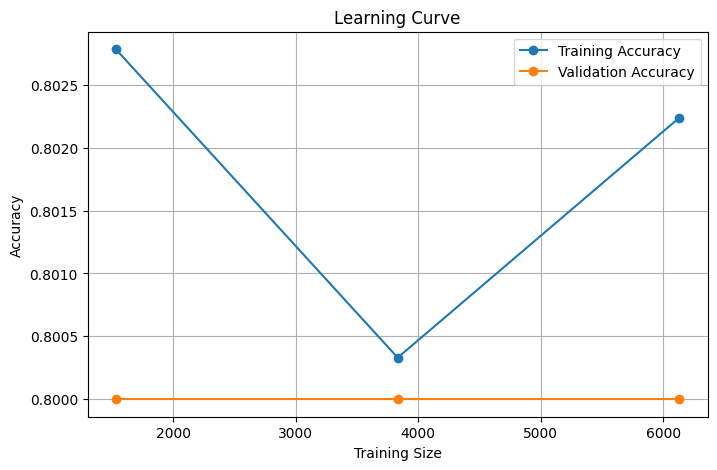

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression

train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(C=1, max_iter=1000),
    X,
    y,
    cv=3,                           
    scoring='accuracy',
    train_sizes=[0.2, 0.5, 0.8],  
    n_jobs=1                       
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, marker='o', label="Training Accuracy")
plt.plot(train_sizes, test_mean, marker='o', label="Validation Accuracy")

plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()